3）主成分分析（PCA）
主成分分析（Principal Component Analysis，PCA）是一种常用的降维技术，通过线性变换将高维数据投影到低维空间，同时保留数据的主要变化模式。


In [20]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [5]:
# 1.读取数据
df = pd.read_csv('./BostonHousing.csv')

# 2、特征与目标分离
X = df.drop('medv', axis=1)
y = df['medv']

print(X.shape, y.shape)

(506, 13) (506,)


In [8]:
# 3. 标准化
# PCA 对特征尺度敏感，必须先标准化（均值=0，方差=1）
scaler = StandardScaler()  # sklearn里面别人已经写好的标准化模型，走一遍出来之后原始数据X就变成（均值=0，方差=1）的X_scaled了
X_scaled = scaler.fit_transform(X)

# 4. 创建 PCA 模型，保留最重要的5个特征
pca = PCA(n_components=5)  # 降到 5 维
X_pca = pca.fit_transform(X_scaled)

In [9]:
# 5. 查看结果
print("原始维度:", X.shape)
print("降维后:", X_pca.shape)
print("每个主成分解释的方差比例:", pca.explained_variance_ratio_)

原始维度: (506, 13)
降维后: (506, 5)
每个主成分解释的方差比例: [0.47129606 0.11025193 0.0955859  0.06596732 0.06421661]


/opt/homebrew/Caskroom/miniconda/base/envs/py311/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20027 (\N{CJK UNIFIED IDEOGRAPH-4E3B}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniconda/base/envs/py311/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniconda/base/envs/py311/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniconda/base/envs/py311/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38477 (\N{CJK UNIFIED IDEOGRAPH-964D}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniconda/base/envs/py311

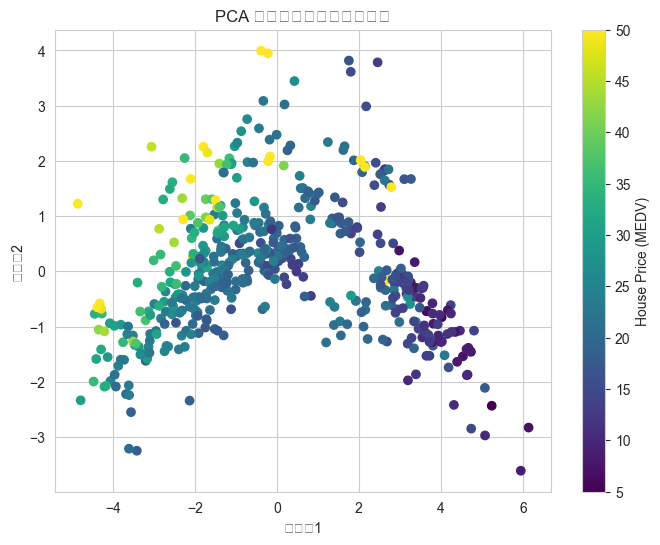

In [12]:
# 6. 可视化
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='viridis')
plt.colorbar(label="House Price (MEDV)")
plt.xlabel("主成分1")
plt.ylabel("主成分2")
plt.title("PCA 降维后的波士顿房价数据")
plt.show()

In [ ]:
# 

In [27]:
# 以下手动将房价数据标准化为（均值=0，方差=1）的数据
import pandas as pd
import numpy as np

df0 = pd.read_csv('./BostonHousing.csv')
df = df0.drop('medv', axis=1)
df_mean = df.mean()
df_std = df.std()
print(df_mean.shape, df_mean, df_mean['age'])
print(df_std.shape, df_std, df_std['age'])

# 使用公式X_std = (X - mean) / std将每一个数据转化为标准化
X_std = (df - df_mean) / df_std
print(X_std.shape, X_std)
print(X_std.mean().round(3))
print(X_std.std().round(3))



(13,) crim         3.613524
zn          11.363636
indus       11.136779
chas         0.069170
nox          0.554695
rm           6.284634
age         68.574901
dis          3.795043
rad          9.549407
tax        408.237154
ptratio     18.455534
b          356.674032
lstat       12.653063
dtype: float64 68.57490118577076
(13,) crim         8.601545
zn          23.322453
indus        6.860353
chas         0.253994
nox          0.115878
rm           0.702617
age         28.148861
dis          2.105710
rad          8.707259
tax        168.537116
ptratio      2.164946
b           91.294864
lstat        7.141062
dtype: float64 28.148861406903617
(506, 13)          crim        zn     indus      chas       nox        rm       age  \
0   -0.419367  0.284548 -1.286636 -0.272329 -0.144075  0.413263 -0.119895   
1   -0.416927 -0.487240 -0.592794 -0.272329 -0.739530  0.194082  0.366803   
2   -0.416929 -0.487240 -0.592794 -0.272329 -0.739530  1.281446 -0.265549   
3   -0.416338 -0.487240 -1.3055

In [36]:

# 以下代码根据上面的X_std手动实现主成分分析PCA
# PCA 的核心思想：
# 通过线性变换将原始特征空间旋转到新的坐标轴上，这些新轴称为主成分，它们按数据方差大小依次排列。
# 1️⃣ 读取并标准化数据

# 2️⃣ 计算协方差矩阵
# 计算协方差矩阵 Σ = (X_stdᵀ X_std) / (n - 1)。
fangcha = X_std.T.dot(X_std) / (X_std.shape[0] - 1)

cov_matrix = np.cov(X_std.T)  # 注意要转置，因为每列是一个特征
print("协方差矩阵形状：", cov_matrix.shape, cov_matrix.shape)
print(fangcha.iloc[0,1], cov_matrix[0,1], fangcha.iloc[0,1] == cov_matrix[0,1])
print(fangcha.iloc[0,2], cov_matrix[0,2], fangcha.iloc[0,2] == cov_matrix[0,2])

# 3️⃣ 求特征值和特征向量
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)


# 4️⃣ 特征值排序（从大到小）, 矩阵的特征值越大表示该该特征越重要，即就越是主成分
sorted_idx = np.argsort(eigen_values)[::-1]
eigen_values = eigen_values[sorted_idx]
eigen_vectors = eigen_vectors[:, sorted_idx]


print("特征值：\n", eigen_values)
print("前3个主成分方向（特征向量）：\n", eigen_vectors[:, :3])

# 5️⃣ 计算解释方差占比
explained_variance_ratio = eigen_values / np.sum(eigen_values)
print("各主成分方差占比：\n", explained_variance_ratio)
print("累计解释方差：\n", np.cumsum(explained_variance_ratio))

# 6️⃣ 取前 k 个主成分进行降维（比如前2个）
k = 2
W = eigen_vectors[:, :k]
X_pca = np.dot(X_std, W)

print("降维后数据形状：", X_pca.shape)
print(X_pca[:5])  # 打印前5行结果

协方差矩阵形状： (13, 13) (13, 13)
-0.20046921966254752 -0.20046921966254752 True
0.4065834114062597 0.40658341140625975 False
特征值：
 [6.12684883 1.43327512 1.24261667 0.85757511 0.83481594 0.65740718
 0.53535609 0.39609731 0.27694333 0.22023782 0.18601437 0.16930298
 0.06350926]
前3个主成分方向（特征向量）：
 [[-0.2509514   0.31525237 -0.24656649]
 [ 0.25631454  0.3233129  -0.29585782]
 [-0.34667207 -0.11249291  0.01594592]
 [-0.00504243 -0.45482914 -0.28978082]
 [-0.34285231 -0.21911553 -0.12096411]
 [ 0.18924257 -0.14933154 -0.59396117]
 [-0.3136706  -0.31197778  0.01767481]
 [ 0.32154387  0.34907     0.04973627]
 [-0.31979277  0.27152094 -0.28725483]
 [-0.33846915  0.23945365 -0.22074447]
 [-0.20494226  0.30589695  0.32344627]
 [ 0.20297261 -0.23855944  0.3001459 ]
 [-0.30975984  0.07432203  0.26700025]]
各主成分方差占比：
 [0.47129606 0.11025193 0.0955859  0.06596732 0.06421661 0.05056978
 0.04118124 0.03046902 0.02130333 0.01694137 0.0143088  0.01302331
 0.00488533]
累计解释方差：
 [0.47129606 0.581548   0.67713389 0.